<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/SARSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (200, 18)

First 5 Rows:
   road_id      road_name       road_type  length_km  lanes  speed_limit_kmh  \
0  RD-0001  Jl. Segment 1  Jalan Kolektor        4.3      4               60   
1  RD-0002  Jl. Segment 2    Jalan Arteri        4.3      4               80   
2  RD-0003  Jl. Segment 3     Jalan Lokal        1.8      2               40   
3  RD-0004  Jl. Segment 4  Jalan Kolektor        1.8      4               60   
4  RD-0005  Jl. Segment 5       Jalan Tol       22.7      4               80   

   capacity_vehicles_per_hour  has_bus_lane  has_bike_lane surface_condition  \
0                        5384             0              0             Cukup   
1                        6132             0              0              Baik   
2                         978             0              0             Cukup   
3                        4160             0              1       Rusak Berat   
4                        6600             1              0              Baik   

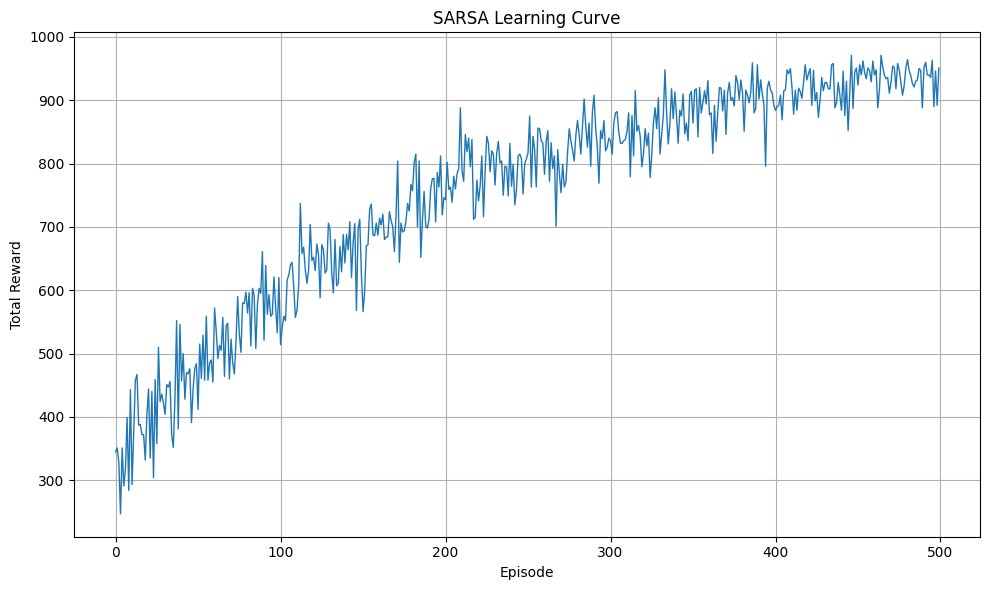

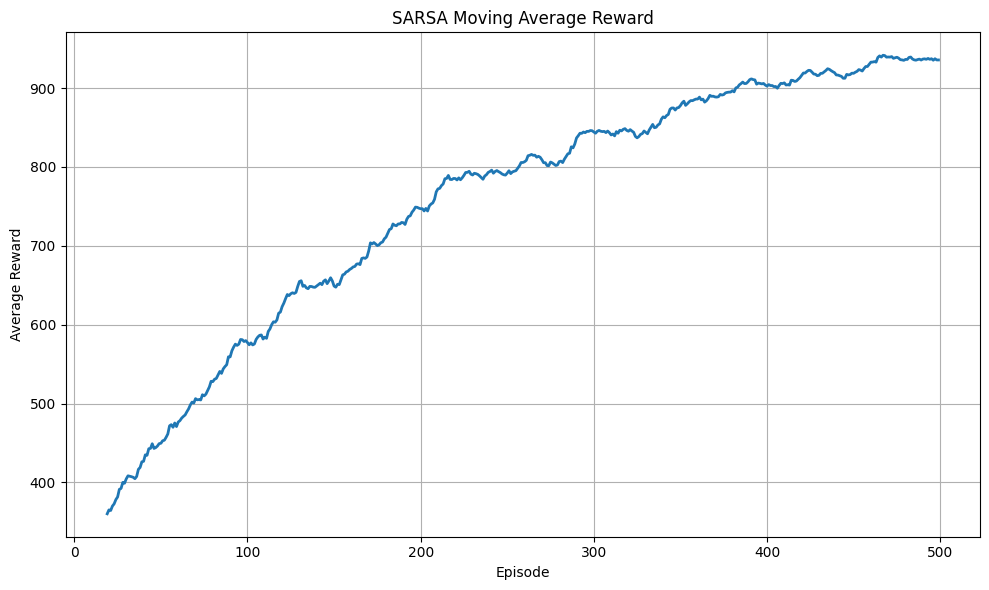

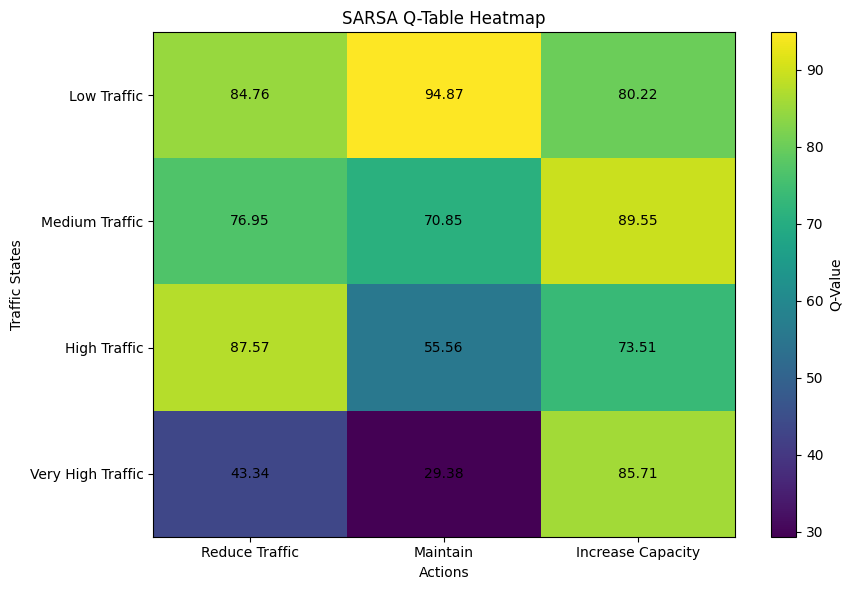

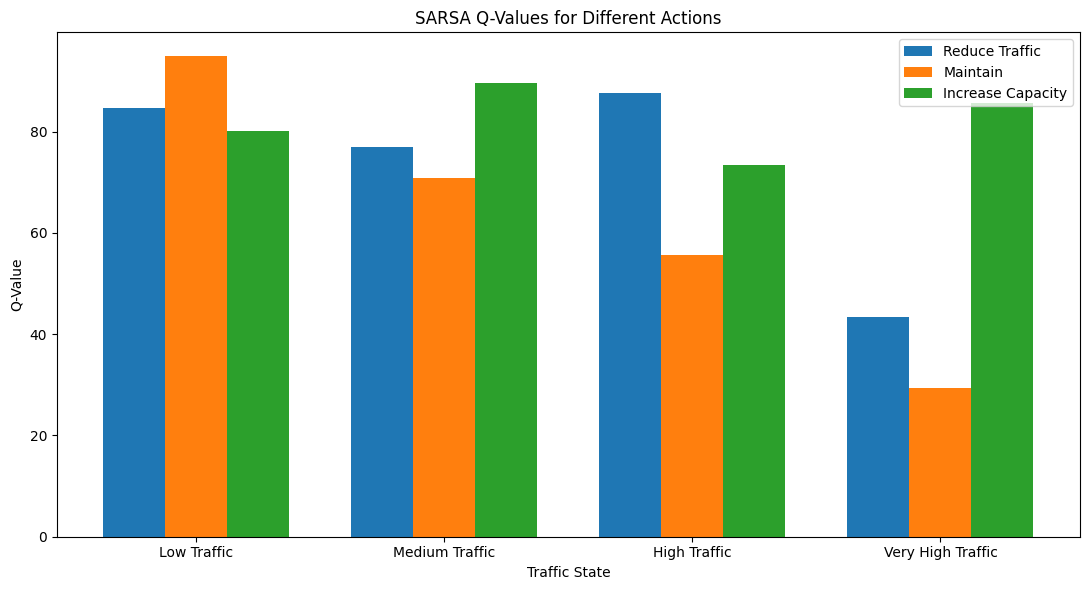

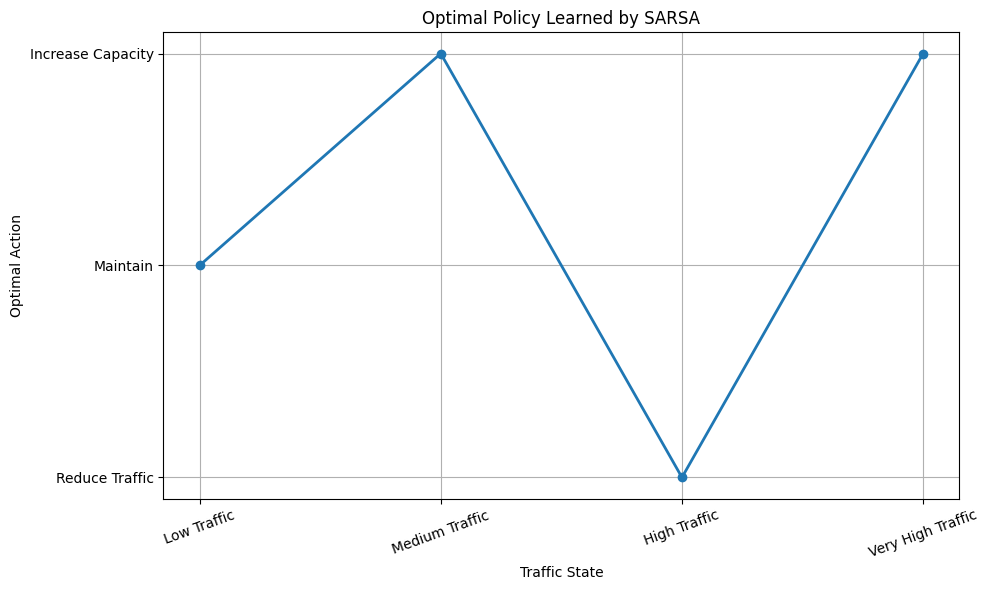

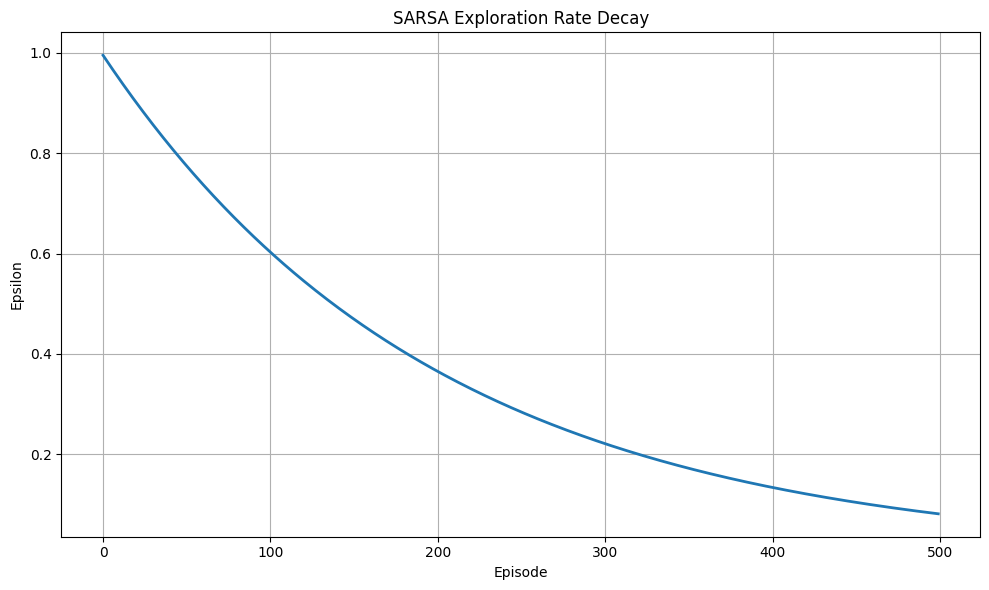

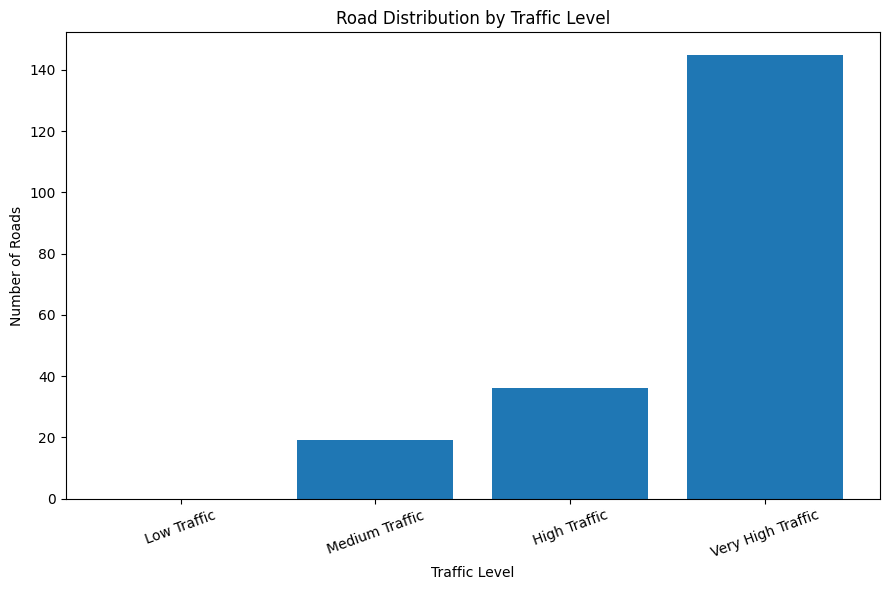


Q-table saved as: sarsa_road_network_results.csv


In [5]:
# ============================================================
# SARSA LEARNING - ROAD NETWORK DATASET
# REINFORCEMENT LEARNING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("road_network.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. SELECT REQUIRED FEATURES
# ============================================================

data = df[
    [
        "road_id",
        "length_km",
        "lanes",
        "speed_limit_kmh",
        "capacity_vehicles_per_hour",
        "avg_daily_traffic"
    ]
].copy()


# ============================================================
# 3. CREATE TRAFFIC RATIO
# ============================================================

# Higher ratio = higher traffic pressure

data["traffic_ratio"] = (
    data["avg_daily_traffic"]
    /
    data["capacity_vehicles_per_hour"]
)


# ============================================================
# 4. CREATE TRAFFIC STATES
# ============================================================

# 0 = Low Traffic
# 1 = Medium Traffic
# 2 = High Traffic
# 3 = Very High Traffic

def get_state(ratio):

    if ratio < 0.50:
        return 0

    elif ratio < 0.80:
        return 1

    elif ratio < 1.00:
        return 2

    else:
        return 3


data["state"] = data["traffic_ratio"].apply(
    get_state
)


# ============================================================
# 5. DEFINE ACTIONS
# ============================================================

# 0 = Reduce Traffic
# 1 = Maintain
# 2 = Increase Capacity

action_names = [
    "Reduce Traffic",
    "Maintain",
    "Increase Capacity"
]

num_states = 4
num_actions = 3


# ============================================================
# 6. REWARD FUNCTION
# ============================================================

def get_reward(state, action):

    # Low traffic
    if state == 0:

        if action == 1:
            return 10

        elif action == 0:
            return 2

        else:
            return -2


    # Medium traffic
    elif state == 1:

        if action == 1:
            return 8

        elif action == 2:
            return 5

        else:
            return 2


    # High traffic
    elif state == 2:

        if action == 2:
            return 10

        elif action == 0:
            return 7

        else:
            return -3


    # Very high traffic
    else:

        if action == 2:
            return 12

        elif action == 0:
            return 8

        else:
            return -8


# ============================================================
# 7. CREATE Q-TABLE
# ============================================================

Q = np.zeros(
    (num_states, num_actions)
)


# ============================================================
# 8. SARSA PARAMETERS
# ============================================================

alpha = 0.1

gamma = 0.9

epsilon = 1.0

epsilon_decay = 0.995

epsilon_min = 0.01

episodes = 500


# ============================================================
# 9. EPSILON-GREEDY POLICY
# ============================================================

def choose_action(state, epsilon):

    if np.random.random() < epsilon:

        return np.random.randint(
            num_actions
        )

    else:

        return np.argmax(
            Q[state]
        )


# ============================================================
# 10. SARSA TRAINING
# ============================================================

episode_rewards = []

episode_steps = []

epsilon_values = []


for episode in range(episodes):

    # Random initial state
    state = np.random.randint(
        num_states
    )

    # Select first action
    action = choose_action(
        state,
        epsilon
    )

    total_reward = 0

    steps = 0


    # --------------------------------------------------------
    # SARSA EPISODE
    # --------------------------------------------------------

    for step in range(100):

        # Get reward
        reward = get_reward(
            state,
            action
        )


        # ----------------------------------------------------
        # Determine Next State
        # ----------------------------------------------------

        if action == 0:

            # Reduce traffic
            next_state = max(
                0,
                state - 1
            )

        elif action == 2:

            # Increase capacity
            next_state = max(
                0,
                state - 1
            )

        else:

            # Maintain
            next_state = state


        # ----------------------------------------------------
        # Choose NEXT action
        # ----------------------------------------------------

        next_action = choose_action(
            next_state,
            epsilon
        )


        # ----------------------------------------------------
        # SARSA UPDATE
        # ----------------------------------------------------

        Q[state, action] = Q[state, action] + alpha * (
            reward
            + gamma * Q[next_state, next_action]
            - Q[state, action]
        )


        # Move to next state and action
        state = next_state

        action = next_action

        total_reward += reward

        steps += 1


    # --------------------------------------------------------
    # DECAY EPSILON
    # --------------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


    episode_rewards.append(
        total_reward
    )

    episode_steps.append(
        steps
    )

    epsilon_values.append(
        epsilon
    )


# ============================================================
# 11. DISPLAY Q-TABLE
# ============================================================

state_names = [
    "Low Traffic",
    "Medium Traffic",
    "High Traffic",
    "Very High Traffic"
]

q_table = pd.DataFrame(
    Q,
    index=state_names,
    columns=action_names
)

print("\n==========================================")
print("FINAL SARSA Q-TABLE")
print("==========================================")

print(q_table)


# ============================================================
# 12. FIND OPTIMAL POLICY
# ============================================================

best_actions = np.argmax(
    Q,
    axis=1
)

print("\n==========================================")
print("OPTIMAL POLICY")
print("==========================================")

for i in range(num_states):

    print(
        f"{state_names[i]} → "
        f"{action_names[best_actions[i]]}"
    )


# ============================================================
# 13. VISUALIZATION 1
#    LEARNING CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    episode_rewards,
    linewidth=1
)

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.title(
    "SARSA Learning Curve"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 14. VISUALIZATION 2
#    MOVING AVERAGE REWARD
# ============================================================

moving_average = pd.Series(
    episode_rewards
).rolling(
    20
).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    moving_average,
    linewidth=2
)

plt.xlabel("Episode")

plt.ylabel(
    "Average Reward"
)

plt.title(
    "SARSA Moving Average Reward"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 15. VISUALIZATION 3
#    Q-TABLE HEATMAP
# ============================================================

plt.figure(figsize=(9, 6))

plt.imshow(
    Q,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Q-Value"
)

plt.xticks(
    range(num_actions),
    action_names
)

plt.yticks(
    range(num_states),
    state_names
)

plt.xlabel("Actions")

plt.ylabel("Traffic States")

plt.title(
    "SARSA Q-Table Heatmap"
)


for i in range(num_states):

    for j in range(num_actions):

        plt.text(
            j,
            i,
            f"{Q[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()


# ============================================================
# 16. VISUALIZATION 4
#    STATE-ACTION BAR CHART
# ============================================================

x = np.arange(
    num_states
)

width = 0.25

plt.figure(figsize=(11, 6))

for action in range(num_actions):

    plt.bar(
        x + action * width,
        Q[:, action],
        width,
        label=action_names[action]
    )

plt.xlabel(
    "Traffic State"
)

plt.ylabel(
    "Q-Value"
)

plt.title(
    "SARSA Q-Values for Different Actions"
)

plt.xticks(
    x + width,
    state_names
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 17. VISUALIZATION 5
#    OPTIMAL POLICY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(num_states),
    best_actions,
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Traffic State"
)

plt.ylabel(
    "Optimal Action"
)

plt.title(
    "Optimal Policy Learned by SARSA"
)

plt.xticks(
    range(num_states),
    state_names,
    rotation=20
)

plt.yticks(
    range(num_actions),
    action_names
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. VISUALIZATION 6
#    EPSILON DECAY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epsilon_values,
    linewidth=2
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Epsilon"
)

plt.title(
    "SARSA Exploration Rate Decay"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 19. ROAD TRAFFIC DISTRIBUTION
# ============================================================

state_counts = data[
    "state"
].value_counts().sort_index()

plt.figure(figsize=(9, 6))

plt.bar(
    state_names,
    [
        state_counts.get(i, 0)
        for i in range(num_states)
    ]
)

plt.xlabel(
    "Traffic Level"
)

plt.ylabel(
    "Number of Roads"
)

plt.title(
    "Road Distribution by Traffic Level"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. SAVE RESULTS
# ============================================================

q_table.to_csv(
    "sarsa_road_network_results.csv"
)

print(
    "\nQ-table saved as:"
    " sarsa_road_network_results.csv"
)